## **ESPECIFICACIONES**

**No olvide duplicar esta notebook para poder editar: File->Save a copy in Drive**

Completar las actividades requeridas dentro de este mismo notebook de Google Colab. Una vez finalizadas las actividades, enviar a la plataforma sea el PDF generado o el link compardio, i.e.,:

1. Un archivo PDF generado en Google Colab desde el menú "Archivo" -> "Imprimir".

2. El enlace público de Google Colab. Para ello, vaya al botón de compartir y cambie la configuración de compartición a "Cualquier persona con el enlace".

 ## **1. DATASET**

In [1]:
# @title
import os
from matplotlib import pyplot as plt   #Libreria que permite hacer plot
from PIL import Image #Procesamiento Digital de IMágenes PIL: Python Image Library
import numpy as np
if not os.path.exists('lfwcrop_grey'):

    !wget http://conradsanderson.id.au/lfwcrop/lfwcrop_grey.zip

    !unzip 'lfwcrop_grey.zip'

filenames = []
images = []

for filename in os.listdir('lfwcrop_grey/faces'):
    filenames.append(filename)
    image = np.array(Image.open(os.path.join('lfwcrop_grey/faces', filename)))
    images.append(image)

images = np.array(images)

print('Total Number of Faces: {}'.format(len(images)))
print(images.shape)
n = 64*64 #dimensión de mis datos (original) n = 4096 features
X = images.reshape(13233, n) # m = 13233 ejemplos de entrenamiento
print(X.shape)

Streaming output truncated to the last 5000 lines.
  inflating: lfwcrop_grey/faces/Herta_Daeubler-Gmelin_0002.pgm  
  inflating: lfwcrop_grey/faces/Richard_Myers_0009.pgm  
  inflating: lfwcrop_grey/faces/Kaye_Young_0001.pgm  
  inflating: lfwcrop_grey/faces/Juan_Ignacio_Chela_0002.pgm  
  inflating: lfwcrop_grey/faces/Paul_Wollnough_0001.pgm  
  inflating: lfwcrop_grey/faces/Carolina_Moraes_0002.pgm  
  inflating: lfwcrop_grey/faces/Charles_Taylor_0007.pgm  
  inflating: lfwcrop_grey/faces/George_W_Bush_0006.pgm  
  inflating: lfwcrop_grey/faces/Ian_Gillan_0001.pgm  
  inflating: lfwcrop_grey/faces/Shaun_Pollock_0001.pgm  
  inflating: lfwcrop_grey/faces/Junichiro_Koizumi_0022.pgm  
  inflating: lfwcrop_grey/faces/Steve_Mariucci_0002.pgm  
  inflating: lfwcrop_grey/faces/George_W_Bush_0214.pgm  
  inflating: lfwcrop_grey/faces/Paul_McCartney_0001.pgm  
  inflating: lfwcrop_grey/faces/Barry_Hinson_0001.pgm  
  inflating: lfwcrop_grey/faces/Huang_Suey-Sheng_0001.pgm  
  inflating: lfwcr


 ## **2. VISUALIZACIÓN DE LAS IMAGENES (DATASET)**

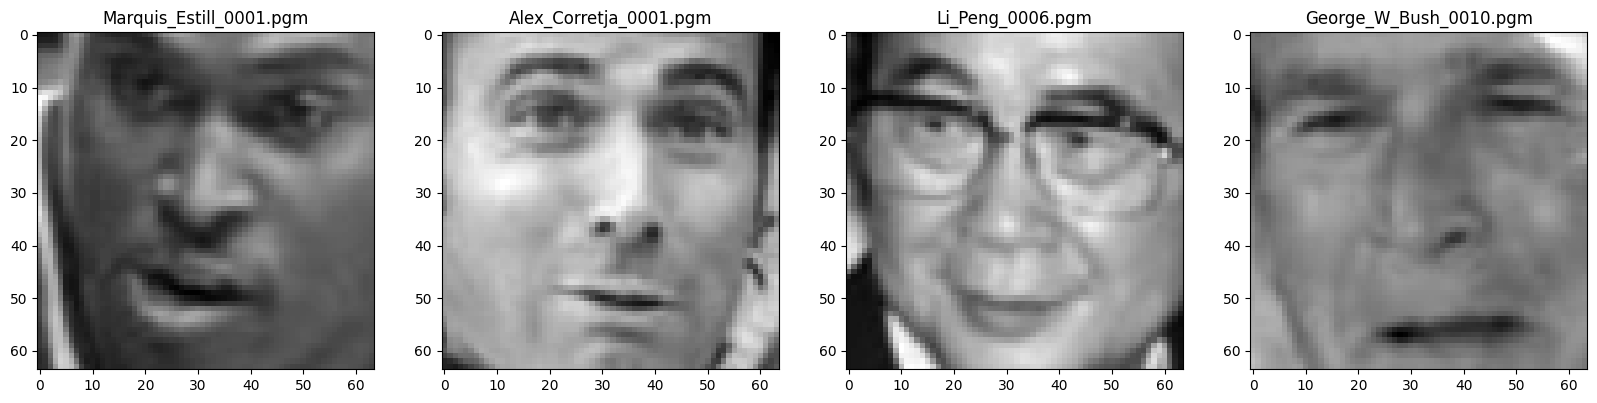

In [2]:
# @title
plt.figure(figsize=(20, 10))  #size de la imagen

num_images = 4 #Numero de imagenes
for i in range(num_images):

    plt.subplot(1, num_images, i+1)
    index = np.random.choice(range(len(images)))
    image = images[index]
    filename=filenames[index]
    plt.imshow(image, 'gray')  #que imprima en grises

    plt.title(filename)  #Imprima el nombre

 ## **3. COMPRESIÓN DE IMAGENES CON SVD**



Paso 1: Compresión de la Imagen (Reducción de la Dimensionalidad)


In [21]:
# @title
# SVD para PCA
print("Calculando SVD...")
X_mean = np.mean(X, axis=0)  # Calcular la media de cada columna
X_centered = X - X_mean  # Centrar los datos
# Aplicar SVD
U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)  # SVD
# Determinar el número de componentes necesarios para retener al menos el 70% de la varianza
# se cambia VR a 0.95 de 0.80 y las expresiones faciales todavía se pierden
# se deja en 0.97
VR = 0.97  # Proporción mínima de varianza explicada deseada
explained_variance = S**2  # Varianza explicada proporcional a los valores singulares al cuadrado (calculamos los eigenvalues)
total_variance = np.sum(explained_variance)  # Varianza total

# Sumar varianza explicada acumulada y determinar el número de componentes
cumulative_variance_ratio = np.cumsum(explained_variance) / total_variance
k = np.argmax(cumulative_variance_ratio >= VR) + 1  # Número de componentes necesarios
print(f"Número de componentes seleccionados para retener al menos el {VR*100}% de la varianza: {k}")

# Reducción de dimensionalidad usando los primeros k componentes
V_reduce = Vt[:k, :]  # Tomar las primeras k filas de Vt
Z = np.dot(X_centered, V_reduce.T)  # Proyectar los datos en el espacio reducido

# Mostrar los resultados
print("Dimensión original:", X.shape)
print("Dimensión reducida:", Z.shape)

# Verificar proporción de varianza explicada por k componentes
variance_retained = np.sum(explained_variance[:k]) / total_variance
print(f"Proporción de varianza explicada por {k} componentes: {variance_retained:.2f}")


Calculando SVD...
Número de componentes seleccionados para retener al menos el 97.0% de la varianza: 276
Dimensión original: (13233, 4096)
Dimensión reducida: (13233, 276)
Proporción de varianza explicada por 276 componentes: 0.97


Paso 2: Reconstrucción de la Imagen

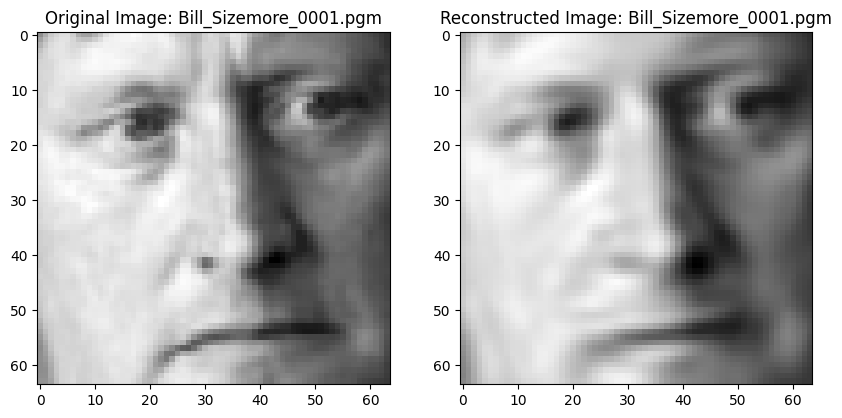

In [24]:
# @title
import random
# Reconstrucción de los datos
X_approx = np.dot(Z, V_reduce) + X_mean  # Transformación inversa al espacio original

# Seleccionar una imagen aleatoria para graficar
# se remueve seed para que no salga la misma imagen
#random.seed(877)
index = random.randint(0,13233)    #Escoge un aleatorio entre 0 a 13233 imaenes
reconstructed_image = X_approx[index] # Reconstruir la imagen
reconstructed_image = reconstructed_image.reshape(64, 64)
original_image = images[index]  # Imagen original

# Mostrar la imagen original y la reconstruida
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title('Original Image: ' + filenames[index]) # Se agrega el nombre
plt.imshow(original_image, cmap='gray')

plt.subplot(1, 2, 2)
plt.title('Reconstructed Image: ' + filenames[index]) # Se agrega el nombre
plt.imshow(reconstructed_image, cmap='gray')

plt.show()

 ## **4. COMPRESIÓN DE IMAGENES CON PCA**

Paso 1: Compresión de la Imagen (Reducción de la Dimensionalidad)


In [14]:
# @title
#Importar librerias
from sklearn import preprocessing
from sklearn.decomposition import PCA

explained_variance = 0.99 #varianza retenida =  varianza explicada = "información" retenida
pca = PCA(explained_variance) #solo construyo el objeto pca, se usa la función, argumento dice que quiere que calcule para la información retenida el 0.99
pca.fit(X) #Implementa [U, S, V^T] = svd(Sigma); Vreduce = V(1:k,:) (ver diapositvas). Selecciona automáticamente k de modo que se retenga 99% de la varianza.
#De cada 13233 de 64*64 = 4096 que son features, con el pca ahora disminuye a 577 features, disminuyendo la calidad de imagen.
z = pca.transform(X) # Implementa z = X_centered.Vreduce (ver diapositivas).
Vreduce = pca.components_.T #Vreduce nxk, reduciendo componentes principales
#puede demorar unos minutos
K = pca.n_components_

#Imprimir información
print("Los datos originales tienen dimensión", X.shape)
print("Los datos comprimidos tienen dimensión", z.shape)
print("El número de componentes principales K es", K, " que retienen el ", explained_variance*100, "% de la varianza")
print("El tam. de Ureduce (matriz de eigenvectors) es", Vreduce.shape)
print("PCA consigue reducir el tamaño en disco al ", K/n*100, "% de su tam. original")

Los datos originales tienen dimensión (13233, 4096)
Los datos comprimidos tienen dimensión (13233, 577)
El número de componentes principales K es 577  que retienen el  99.0 % de la varianza
El tam. de Ureduce (matriz de eigenvectors) es (4096, 577)
PCA consigue reducir el tamaño en disco al  14.0869140625 % de su tam. original


Paso 2: Reconstrucción de la Imagen

Label John_Allen_Muhammad_0011.pgm


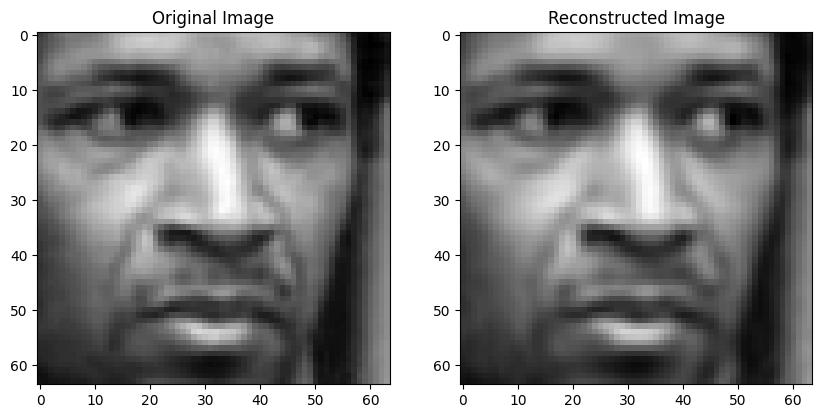

In [26]:
# @title
import random     #Se escoge 1 de todas las imagenes
# se quita el seed para que no salga siempre la misma imagen
#random.seed(a=877)

#Implementa x_approx = z.Vreduce+mean
X_approx = pca.inverse_transform(z)
# índice de la imagen a graficar
index = random.randint(0,13233)    #Escoge un aleatorio entre 0 a 13233 imagenes
reconstructed_image = X_approx[index]
reconstructed_image = reconstructed_image.reshape(64, 64)
print('Label {}'.format(filenames[index]))
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)    #Imprime 2 imagenes la original posicion 1
plt.title('Original Image')
plt.imshow(images[index], 'gray')

plt.subplot(1, 2, 2) #Imprime 2 imagenes la reconstruida posicion 1
plt.title('Reconstructed Image')
plt.imshow(reconstructed_image, 'gray')

## **5. ACTIVIDAD 1: COMPRESIÓN DE IMAGENES**

**5.1 Varianza retenida vs Numero de componentes (k)**

Grafique la varianza retenida en función del número de componentes principales retenidos k. Para esto, modifique la variable `explained_variance` con los siguientes valores: 0.99, 0.75, 0.3

Para cada valor, verifique el número de componentes principales retenidos k.

In [ ]:
#Insertar código

from sklearn import preprocessing
from sklearn.decomposition import PCA
varianza = [0.99, 0.75,0.3]
num_compo_k=[]

for x in varianza:

  explained_variance = x #varianza retenida =  varianza explicada = "información" retenida porcentaje
  #inserte el codigo aqui



#aqui codigo para dibujar
plt.figure(figsize=(10, 5))
plt.title('Varianza vs k components')
plt.plot(num_compo_k,varianza)


**5.2 Calidad vs. Componente**

Tomar una imagen propia (selfie) en escala de grises y aplicar PCA para obtener una representación comprimida. Reconstruir la imagen utilizando componentes que preserven el 70% y el 99% de la varianza, y comparar visualmente las reconstrucciones con la imagen original.



**Compresión**

In [ ]:
#Librerias
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 1 Cargar imagen
img = Image.open("mi_foto.jpeg")  # formatos aceptados jpeg, png, jpg
img_gray = img.convert("L")  # convertimos a escala de grises
img_resized = img_gray.resize((512, 512), Image.LANCZOS)  # redimensionar la imagen
img_array = np.array(img_resized, dtype=float)        # obtener la matriz numérica de la imagen


# 2. Aplicar PCA para compresión
# img_array tiene dimensión (512, 512)
#
# En este ejercicio:
# - cada fila se considera una muestra      -> 512 muestras
# - cada columna se considera una feature  -> 512 features
#
# Aplicar PCA conservando:
# a) 70% de la varianza
# b) 99% de la varianza

# insertar su código de PCA aquí


# 3. Reconstrucción
# Reconstruir la imagen utilizando inverse_transform()

# insertar su código para reconstruir la imagen


# 4. Visualización
# Mostrar:
# - imagen original
# - reconstrucción con 70% de varianza
# - reconstrucción con 99% de varianza

# insertar su código de visualización



# 5. Mostrar información
# Para cada caso (70% y 99%), mostrar:
#
# - dimensión de la imagen original
# - dimensión de la representación comprimida
# - número de componentes principales utilizados
# - porcentaje de varianza retenida

## **ACTIVIDAD 2: Uso de DataSet Genérico**

Escoger un dataSet genérico de interés del repositorio proporcionado y aplicar PCA.

[UC Irvine Machine Learning Repository](https://archive.ics.uci.edu/)  

In [ ]:
# Instalar
!pip install -q ucimlrepo
# Link: https://archive.ics.uci.edu/dataset/360/air+quality
# PCA puro sobre features de Air Quality (UCI id=360)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from ucimlrepo import fetch_ucirepo

# 1) Cargar dataset (Cambiar el número de id para el dataSet Escogido)
air_quality = fetch_ucirepo(id=360)
X = air_quality.data.features   # solo features

# Ingresar su código aqui (no olvidar los loadings para poder discutir los datos)

# **RESPONDER**

¿El PCA fue útil en este dataset?

¿Se lograron patrones visibles (agrupaciones, separaciones)?, si es así, escribir su interpretación sobre los resultados